In [63]:
from bisect import bisect_right


class CubicSpline1D:
    """
    Натуральный кубический сплайн по точкам (x_i, y_i).

    - x_i должны быть строго возрастающими.
    - Граничные условия: S''(x_0) = 0, S''(x_n) = 0.
    """

    def __init__(self, points):
        # ---------- 1. Разбор входных данных ----------
        xs, ys = zip(*points)
        self.x = list(xs)
        self.y = list(ys)

        n = len(self.x) - 1  # число интервалов
        if n < 1:
            raise ValueError("Нужно минимум 2 точки для сплайна")

        # ---------- 2. h_i = x_{i+1} - x_i ----------
        h = [self.x[i + 1] - self.x[i] for i in range(n)]
        if any(hi <= 0 for hi in h):
            raise ValueError("x_i должны быть строго возрастающими")

        self.h = h

        # ---------- 3. Сборка трёхдиагональной системы для M_i ----------
        # Неизвестные: M_0 .. M_n, но M_0 = M_n = 0 (натуральный),
        # значит решаем систему только для i = 1..n-1 (m = n-1 уравнений).
        m = n - 1
        if m > 0:
            alpha = [0.0] * m
            beta  = [0.0] * m
            gamma = [0.0] * m
            rhs   = [0.0] * m

            for k in range(m):
                i = k + 1  # реальный индекс узла (1..n-1)

                alpha[k] = h[i - 1]
                beta[k]  = 2.0 * (h[i - 1] + h[i])
                gamma[k] = h[i]

                rhs[k] = 6.0 * (
                    (self.y[i + 1] - self.y[i])   / h[i] -
                    (self.y[i]     - self.y[i-1]) / h[i-1]
                )

            # ---------- 4. Метод прогонки (Thomas) ----------
            # Прямой ход
            c = [0.0] * m
            d = [0.0] * m

            # i = 0
            c[0] = gamma[0] / beta[0]
            d[0] = rhs[0]   / beta[0]

            # i = 1..m-1
            for k in range(1, m):
                denom = beta[k] - alpha[k] * c[k - 1]
                c[k] = gamma[k] / denom
                d[k] = (rhs[k] - alpha[k] * d[k - 1]) / denom

            # Обратный ход: находим M_1..M_{n-1}
            M = [0.0] * (n + 1)  # M_0..M_n, сразу заполняем
            M[n - 1] = d[m - 1]
            for k in range(m - 2, -1, -1):
                i = k + 1  # узел
                M[i] = d[k] - c[k] * M[i + 1]

            # Граничные условия натурального сплайна
            M[0] = 0.0
            M[n] = 0.0
        else:
            # Если всего один интервал (2 точки) – просто прямая
            M = [0.0, 0.0]

        self.M = M

        # ---------- 5. Предвычисляем A_i, B_i для формулы сплайна ----------
        A = [0.0] * n
        B = [0.0] * n
        for i in range(n):
            hi = h[i]
            A[i] = self.y[i]   - M[i]   * hi**2 / 6.0
            B[i] = self.y[i+1] - M[i+1] * hi**2 / 6.0

        self.A = A
        self.B = B

    # ---------- 6. Поиск интервала ----------
    def _find_interval(self, xq):
        """
        Найти i такое, что x[i] <= xq <= x[i+1].
        Используем bisect для логарифмического поиска.
        """
        if xq <= self.x[0]:
            return 0
        if xq >= self.x[-1]:
            return len(self.x) - 2
        # bisect_right вернет позицию > xq, вычитаем 1
        i = bisect_right(self.x, xq) - 1
        return max(0, min(i, len(self.x) - 2))

    # ---------- 7. Вычисление значения сплайна ----------
    def __call__(self, xq):
        """
        Вернуть S(xq).
        xq может быть числом или итерируемым объектом (список, numpy-массив и т.п.).
        """
        # Если это "скаляр" (int/float)
        if isinstance(xq, (int, float)):
            return self._eval_scalar(float(xq))
        # Иначе считаем поэлементно
        return [self._eval_scalar(float(x)) for x in xq]

    def _eval_scalar(self, xq: float) -> float:
        i = self._find_interval(xq)
        xi, xi1 = self.x[i], self.x[i+1]
        hi = self.h[i]
        Mi, Mi1 = self.M[i], self.M[i+1]
        Ai, Bi = self.A[i], self.B[i]

        dxL = xi1 - xq
        dxR = xq - xi

        term1 = Mi  * dxL**3 / (6.0 * hi)
        term2 = Mi1 * dxR**3 / (6.0 * hi)
        term3 = Ai  * dxL     / hi
        term4 = Bi  * dxR     / hi

        return term1 + term2 + term3 + term4

    # ---------- 8. Производная S'(x) (по желанию) ----------
    def derivative(self, xq):
        """
        Вернуть S'(xq).
        """
        if isinstance(xq, (int, float)):
            return self._eval_deriv_scalar(float(xq))
        return [self._eval_deriv_scalar(float(x)) for x in xq]

    def _eval_deriv_scalar(self, xq: float) -> float:
        i = self._find_interval(xq)
        xi, xi1 = self.x[i], self.x[i+1]
        hi = self.h[i]
        Mi, Mi1 = self.M[i], self.M[i+1]
        Ai, Bi = self.A[i], self.B[i]

        dxL = xi1 - xq
        dxR = xq - xi

        # S'(x) =
        # - Mi  * dxL^2 / (2 h_i) + Mi1 * dxR^2 / (2 h_i) + (B_i - A_i) / h_i
        term1 = - Mi  * dxL**2 / (2.0 * hi)
        term2 =   Mi1 * dxR**2 / (2.0 * hi)
        term3 = (Bi - Ai) / hi

        return term1 + term2 + term3


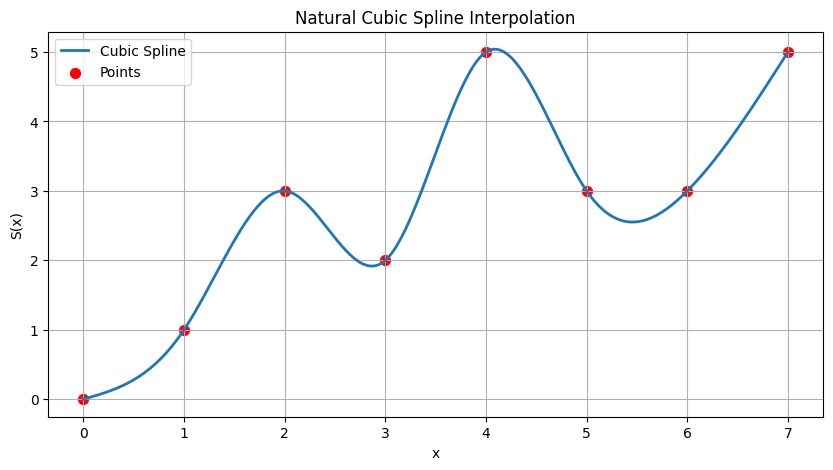

In [71]:
from matplotlib import pyplot as plt

# берём все точки
points = (
    (0, 0),
    (1, 1),
    (2, 3),
    (3, 2),
    (4, 5),
    (5, 3),
    (6, 3),
    (7, 5),
)

# строим сплайн
spline = CubicSpline1D(points)

# генерируем сетку для отображения
xp = [i / 50 for i in range(0, 7 * 50 + 1)]   # шаг 0.02 примерно
ys = spline(xp)                               # значения сплайна

# исходные точки (для проверки интерполяции)
xs_pts = [p[0] for p in points]
ys_pts = [p[1] for p in points]

# рисуем
plt.figure(figsize=(10, 5))
plt.plot(xp, ys, label="Cubic Spline", linewidth=2)
plt.scatter(xs_pts, ys_pts, color="red", s=50, label="Points")
plt.grid(True)
plt.legend()
plt.title("Natural Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("S(x)")
plt.show()


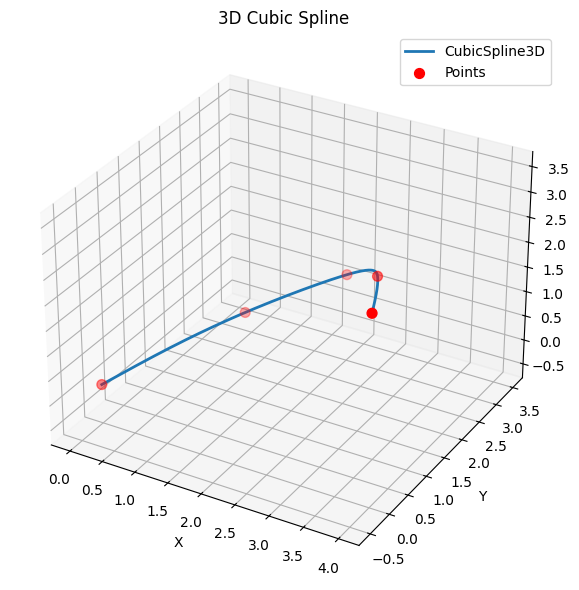

In [73]:
from cubic_spline import CubicSpline3D
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # важно для 3D
# считаем, что CubicSpline1D и CubicSpline3D уже импортированы/определены


# Пример 3D-точек (можешь заменить на свои, например CA-координаты)
points3d = [
    (0.0, 0.0, 0.0),
    (1.0, 2.0, 0.5),
    (2.0, 3.0, 1.0),
    (3.0, 2.0, 2.0),
    (4.0, 0.0, 3.0),
]

# Строим 3D-сплайн
spline3d = CubicSpline3D(points3d)

# Сэмплируем N точек на кривой
N = 300
curve_pts = spline3d.sample(N)  # список (x, y, z)

xs_curve = [p[0] for p in curve_pts]
ys_curve = [p[1] for p in curve_pts]
zs_curve = [p[2] for p in curve_pts]

# Отдельно исходные точки
xs_pts = [p[0] for p in points3d]
ys_pts = [p[1] for p in points3d]
zs_pts = [p[2] for p in points3d]


# --- Функция, чтобы сделать одинаковый масштаб по осям (честное 3D) ---
def set_axes_equal(ax):
    """Сделать масштаб по всем осям одинаковым."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]

    max_range = max(x_range, y_range, z_range) / 2.0

    x_middle = (x_limits[0] + x_limits[1]) / 2.0
    y_middle = (y_limits[0] + y_limits[1]) / 2.0
    z_middle = (z_limits[0] + z_limits[1]) / 2.0

    ax.set_xlim3d([x_middle - max_range, x_middle + max_range])
    ax.set_ylim3d([y_middle - max_range, y_middle + max_range])
    ax.set_zlim3d([z_middle - max_range, z_middle + max_range])


# --- Рисуем ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Гладкая кривая
ax.plot(xs_curve, ys_curve, zs_curve, label='CubicSpline3D', linewidth=2)

# Опорные точки
ax.scatter(xs_pts, ys_pts, zs_pts, color='red', s=50, label='Points')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Cubic Spline')

ax.legend()
ax.grid(True)

# Выравниваем масштаб
set_axes_equal(ax)

plt.tight_layout()
plt.show()

